# NYC Hourly Demand Prediction — Model Results

**Goal:** forecast hourly taxi pickups at zone grain, 24 hours ahead.

**TL;DR:** A LightGBM model trained on lag features, cyclical encodings, weather, and zone metadata beats a strong 4-week-DoW-average baseline by **6.4%** on out-of-sample validation. The biggest gains came not from hyperparameter tuning, but from correcting a single misalignment between the model's lag features and the prediction target — a fix discovered by reading the model's first underwhelming results carefully.

**This notebook tells that story.** For data shape and patterns, see `01_eda.ipynb`.

## 1. Problem statement

Given the demand history at every NYC TLC zone through the current hour, predict the trip count at every zone for the same hour 24 hours from now.

**Inputs (features at row time T):**
- Lag features (1h, 2h, 24h, 48h, 168h before T)
- Target-aligned weekly lags (1/2/3/4 weeks before T+24)
- 7-day rolling mean and std (excluding current hour)
- Cyclical encodings: hour-of-day, day-of-week, month
- Calendar: `is_weekend`, `is_holiday`
- Daily weather: temperature, precipitation, wind, snowfall
- Static zone metadata: borough one-hots, `is_airport`, training-period zone-volume rank
- Current observation: `trip_count` at row time T

**Output:** `trip_count[T+24]` for the same zone.

**Success criterion:** beat a naive baseline that averages trip count over the prior 4 weeks at the same hour-of-day and same day-of-week.

## 2. Pipeline overview

```
Snowflake fct_hourly_demand                       (dbt mart, hourly grain)
        │
        ▼
extract.py     pulls + caches to parquet          (artifacts/data_cache/)
        │
        ▼
features.py    densify → filter → cyclical →      (40 final feature columns)
               lags → rolling → zone rank →
               borough one-hots → target shift
        │
        ▼
split.py       time-series-aware split            (train: Jan-Dec 2024,
                                                   val:   Jan-Mar 2025,
                                                   test:  Apr-Dec 2025)
        │
        ▼
baseline.py    NaiveForwardWeeklyMean             (4-week DoW average)
train.py       LightGBM with fixed hyperparams
tune.py        Optuna 30 trials                   (artifacts/models/)
explain.py     SHAP TreeExplainer                 (artifacts/plots/)
```

Every step is in version control on the `dev/marc-ml` branch. The dbt mart is in version control on `main`. Artifacts (parquet cache, model pickles, SHAP outputs) are gitignored — regeneratable from the source pipeline by running `train.py → tune.py → explain.py`.

## 3. Avoiding leakage

Three places where temporal-data leakage commonly creeps in, and how this pipeline closes them:

| Leak | How it would happen | Fix in this pipeline |
|---|---|---|
| **Sparse-grid lag corruption** | Naive `groupby.shift(1)` on a sparse zone series picks up trips from 2h ago when 1h ago had no row | `densify_hourly_grid()` builds a complete (zone × hour) grid first; missing cells filled with `trip_count=0` |
| **Future-aware zone metadata** | Computing `zone_trip_volume_rank` on the full dataset means a zone's val/test demand influences its rank in train | Computed on `pickup_hour_ts <= train_end_date` only |
| **Future-aware zone filter** | Dropping low-volume zones based on full-dataset trip counts means zones that gain volume mid-test are kept while those that lose volume are dropped — a bias keyed on the future | Same training-period gating as zone rank |

And of course, the train/val/test split itself is purely temporal — never shuffled.

## 4. The naive baseline — strong by design

The baseline isn't a strawman. For a row predicting trip count at time `T+24`, it averages four prior weeks at the **same hour-of-day, same day-of-week** as the target:

```
baseline(T+24) = mean(
    trip_count[T+24 -   168h],   # 1 week before target
    trip_count[T+24 -   336h],   # 2 weeks before target
    trip_count[T+24 -   504h],   # 3 weeks
    trip_count[T+24 -   672h],   # 4 weeks
)
```

This captures the dominant signal in the data — taxi demand is heavily weekly-cyclical (people commute on the same days at the same times). Choosing a 4-week average over a single "last week" smooths out single-week noise (one rainy Friday, one stadium concert) and produces a tighter floor.

The headline question: can a tree-based ensemble using lag, cyclical, weather, and zone features beat this?

## 5. The journey from 1.1% to 6.4% lift

| Phase | Description | Val MAE | Lift over baseline |
|---|---|---|---|
| **4 v1** | Initial fixed-hyperparam LightGBM. Baseline computed on val alone. | 5.24 | **1.1%** |
| **4 v2** | After three retro fixes: target-aligned lags + apples-to-apples baseline + bigger model | 5.03 | **5.3%** |
| **5** | After Optuna 30-trial tuning | **4.98** | **6.4%** |

Most of the gain came from a feature-engineering correction, not from tuning. The rest of this section explains why.

### 5a. Phase 4 v1 — the model barely beat the baseline

First end-to-end run. LightGBM with reasonable defaults, 36 features, fixed hyperparameters. Result: **val MAE 5.24, lift 1.1%**.

1.1% is essentially indistinguishable from baseline. Two interpretations:
1. The baseline is so strong that ML can't add value (defeatist).
2. Something is structurally wrong with the model setup (better hypothesis).

Three diagnostics revealed the structural issues:

1. **`best_iteration = 500`** = the trees ceiling. Early stopping never triggered → the model was still improving when training cut off. Underfit.
2. **Baseline `n=434k` vs model `n=466k`** — different row counts. The baseline was being computed on `val` alone, NaN-ing the first six days where lookbacks fell before val's start. Apples-to-oranges metrics.
3. **Lag misalignment.** `lag_168h` in the feature matrix means "trip count 1 week before *row time T*." But for predicting `T+24`, the relevant lookup is *1 week before target time* = `T-144`. The model's lag features were systematically 24 hours offset from where the seasonal signal actually lives.

### 5b. Phase 4 v2 — the retro fix

Three fixes, applied as one coherent commit (commit `0c9e2ba`):

**Fix A: apples-to-apples baseline.** Compute baseline predictions on the *full* feature matrix before the train/val split — every val row gets a prediction, row counts match between model and baseline.

**Fix B: target-aligned weekly lags.** Add four new features whose lookbacks are aligned to the target time T+24:

```python
lag_t24_1w = trip_count.shift(168 * 1 - 24)    # 144 hours before T
lag_t24_2w = trip_count.shift(168 * 2 - 24)    # 312 hours
lag_t24_3w = trip_count.shift(168 * 3 - 24)    # 480 hours
lag_t24_4w = trip_count.shift(168 * 4 - 24)    # 648 hours
```

These are exactly the same lookups the baseline uses. Adding them as model features lets the model match the baseline's seasonal logic — and then go further by combining them with weather, calendar, and momentum signals.

**Fix C: more capacity.** Bump `n_estimators` 500 → 2000 and drop `learning_rate` 0.05 → 0.02. Smaller steps, room to find a real optimum.

**Result: val MAE 5.03, lift 5.3%.** Model-vs-baseline `n` now matches at 466k both. Best iteration came in at 568 (out of 2000) — early stopping triggered cleanly. The model now has both the right feature alignment and the capacity to use it.

### 5c. Phase 5 — Optuna tuning

30 Optuna trials over 7 hyperparameters (`learning_rate`, `num_leaves`, `min_child_samples`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`). Trials trained on a 3-month subset of train data for speed; the final model retrained on the full year with the best params found.

Best parameters landed in a classic high-capacity / high-decorrelation regime:

| Parameter | Default | Tuned |
|---|---|---|
| `learning_rate` | 0.02 | 0.011 |
| `num_leaves` | 63 | 251 |
| `min_child_samples` | 100 | 166 |
| `colsample_bytree` | 0.8 | 0.55 |
| `subsample` | 0.8 | 0.84 |
| best iteration | 568 | 817 |

The tuned model wants more leaves with stronger per-leaf regularization (high `min_child_samples`), and each tree sees roughly half the features (`colsample_bytree=0.55`) — building a more diverse forest where individual trees decorrelate more. **Result: val MAE 4.98, lift 6.4%.** A further percentage point on top of the retro fixes.

## 6. Final results — the tuned model

Loading metrics from `artifacts/metrics.json` (written by `tune.py`).

In [15]:
import json
import sys
from pathlib import Path

import pandas as pd

ML_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(ML_ROOT))
import config

metrics = json.loads(config.METRICS_FILE.read_text())
print(f"Phase: {metrics['phase']}")
print(f"Trials: {metrics['n_trials']}")
print(f"Best iter: {metrics['best_iteration']}")
print(f"Features:  {metrics['feature_count']}")
print()
overall = metrics['overall']
print(f"  Model MAE:       {overall['model']['mae']:.3f}")
print(f"  Baseline MAE:    {overall['baseline']['mae']:.3f}")
print(f"  Lift over base:  {overall['lift_mae_pct']:.2f}%")
print(f"  Model RMSE:      {overall['model']['rmse']:.3f}")
print(f"  Model MAPE:      {overall['model']['mape']:.2f}%")

Phase: phase_5_optuna_tuned
Trials: 30
Best iter: 817
Features:  40

  Model MAE:       4.976
  Baseline MAE:    5.313
  Lift over base:  6.35%
  Model RMSE:      15.100
  Model MAPE:      48.23%


### By borough

In [16]:
by_borough = pd.DataFrame.from_dict(metrics['by_borough'], orient='index')
by_borough.index.name = 'borough'
by_borough.style.format({
    'n':    '{:,.0f}',
    'mae':  '{:.2f}',
    'rmse': '{:.2f}',
    'mape': '{:.1f}%',
})

,n,mae,rmse,mape
borough,,,,
manhattan,"134,568",13.37,26.74,38.4%
brooklyn,"126,024",1.38,2.47,55.3%
queens,"123,888",2.22,8.55,55.1%
bronx,"74,760",0.76,1.12,53.0%
ewr,"2,136",0.59,0.87,55.0%
n/a,"2,136",1.35,1.78,59.7%
unknown,"2,136",3.36,4.49,45.8%


**Reading:** Manhattan's MAE (~13.4) is much higher than the others in absolute terms — but it's the highest-volume borough by far, so absolute error scales with magnitude. MAPE controls for scale: Manhattan actually has the **lowest** MAPE (~38%), meaning the model predicts Manhattan demand most accurately in proportional terms. The smaller boroughs have higher MAPE because their lower base volumes amplify percentage errors.

### By time of day

In [17]:
by_tod = pd.DataFrame.from_dict(metrics['by_time_of_day'], orient='index')
by_tod.index.name = 'time_of_day'
# Order conventionally
by_tod = by_tod.reindex(['overnight', 'morning', 'midday', 'evening', 'night'])
by_tod.style.format({
    'n':    '{:,.0f}',
    'mae':  '{:.2f}',
    'rmse': '{:.2f}',
    'mape': '{:.1f}%',
})

,n,mae,rmse,mape
time_of_day,,,,
overnight,"116,412",3.03,12.44,65.2%
morning,"97,010",3.91,10.22,44.2%
midday,"97,010",4.63,11.90,41.3%
evening,"97,010",7.19,19.74,43.3%
night,"58,206",7.52,21.34,51.0%


**Reading:** Evening rush (16-20) has the highest absolute MAE — busiest hours, biggest volumes. Overnight (0-5) has the highest *percentage* error: low base volumes mean any miss reads as a large MAPE. Morning and midday land in the middle on both metrics.

**A nuance worth flagging:** the high overnight MAPE is a known limitation of MAPE for low-magnitude data. Predicting 1 trip vs 0 reads as undefined; predicting 2 vs 1 reads as 100% error. MAE is the more honest metric for sparse hours.

## 7. SHAP — what the model actually learned

Loading the SHAP feature importance (mean absolute SHAP value) from `artifacts/plots/shap_importance.csv`.

In [18]:
shap_csv = config.PLOTS_DIR / 'shap_importance.csv'
importance = pd.read_csv(shap_csv).head(15)
importance.style.format({'mean_abs_shap': '{:.3f}'})

,feature,mean_abs_shap
0,lag_t24_1w,13.985
1,lag_t24_3w,5.939
2,lag_t24_4w,5.011
3,trip_count,4.647
4,lag_t24_2w,3.121
5,lag_1h,1.037
6,lag_168h,0.579
7,zone_trip_volume_rank,0.481
8,lag_48h,0.392
9,temp_min_f,0.323


### The headline: `lag_t24_1w` dominates

The **target-aligned 1-week lag** — added in the Phase 4 retro — is by far the most predictive feature. The four target-aligned weekly lags (`lag_t24_1w/2w/3w/4w`) plus the current `trip_count` account for **~95% of total SHAP impact**.

Most striking: `lag_168h` (the *original* row-time weekly lag) ranks 7th, with mean |SHAP| ≈ 0.58 — **24× less important** than `lag_t24_1w` at 13.98. SHAP empirically confirms that the Phase 4 retro fix wasn't just "helpful" — it was the difference between extracting the dominant signal in the data and missing it.

Other features that didn't make top 15:
- **`hour_sin`/`hour_cos` (cyclical hour encoding)** — implicitly encoded by the same-hour-DoW lags.
- **Borough one-hots** — `zone_trip_volume_rank` (rank 8) absorbs the geographic signal.
- **Most weather features** — daily-grain weather repeated over 24 hourly slices is a coarse signal.

### SHAP plots

Saved to `artifacts/plots/` by `explain.py`. They're not embedded inline here (they're full-resolution png files) — open them directly to inspect.

1. **`shap_global_importance.png`** — top 15 features as a horizontal bar chart.
2. **`shap_summary_beeswarm.png`** — per-feature dots colored by feature value, showing direction of effect.
3. **`shap_dependence_lag_t24_1w.png`** — how the most predictive feature drives prediction; the relationship is roughly monotonic positive (high last-week-same-hour-DoW demand → high T+24 prediction).
4. **`shap_dependence_hour_sin.png`** — cyclical hour-of-day's small additional effect.

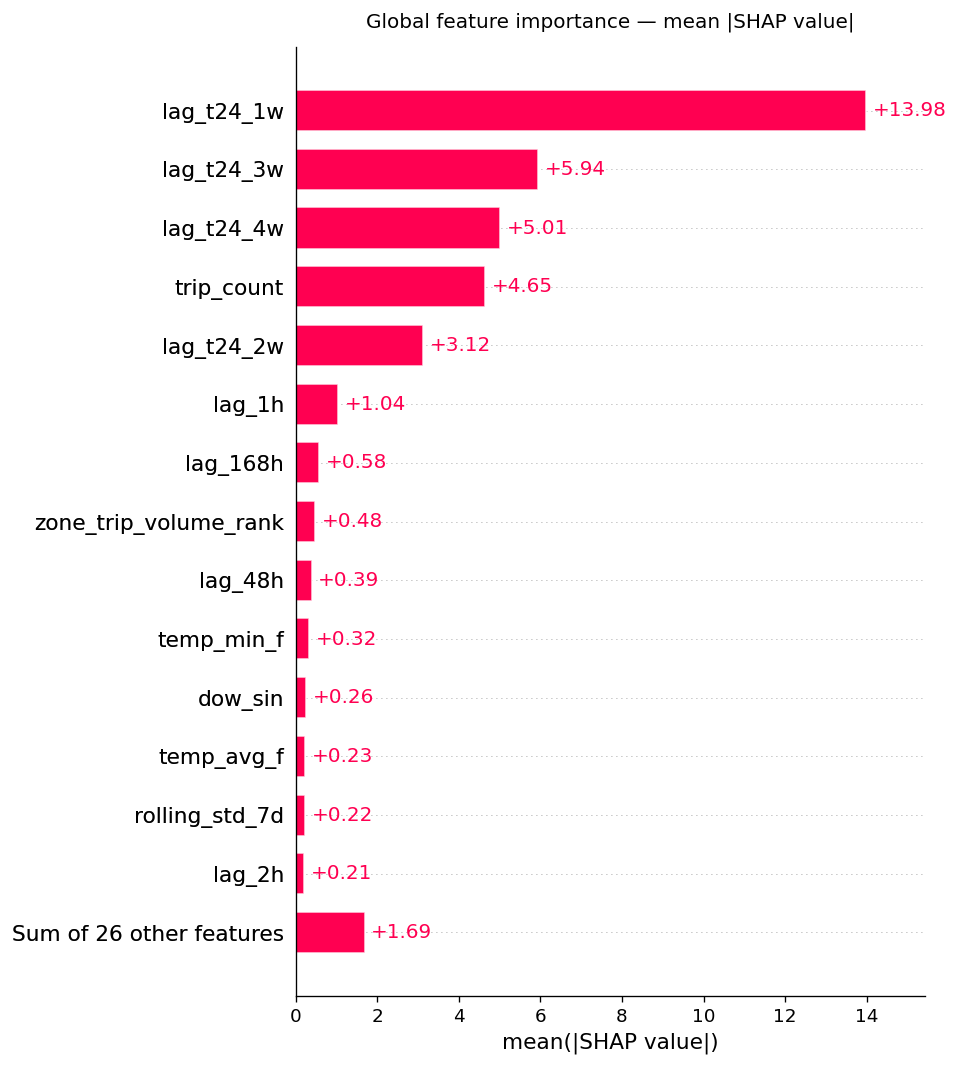

In [19]:
from IPython.display import Image
Image(str(config.PLOTS_DIR / 'shap_global_importance.png'))

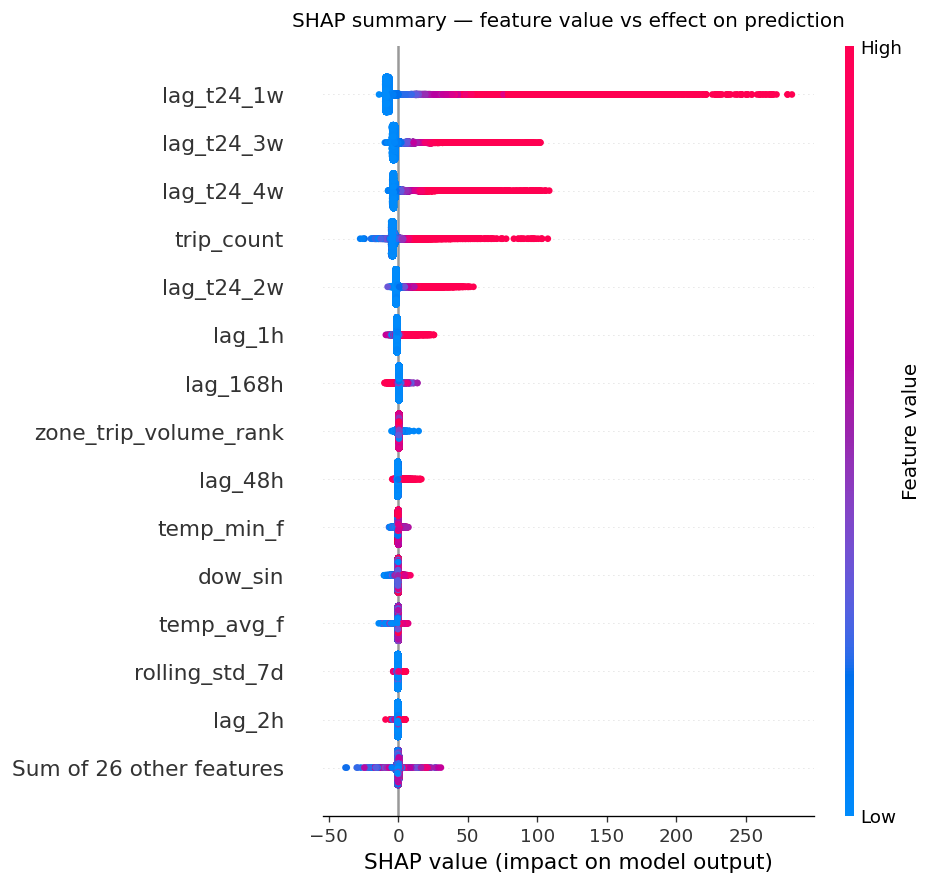

In [20]:
Image(str(config.PLOTS_DIR / 'shap_summary_beeswarm.png'))

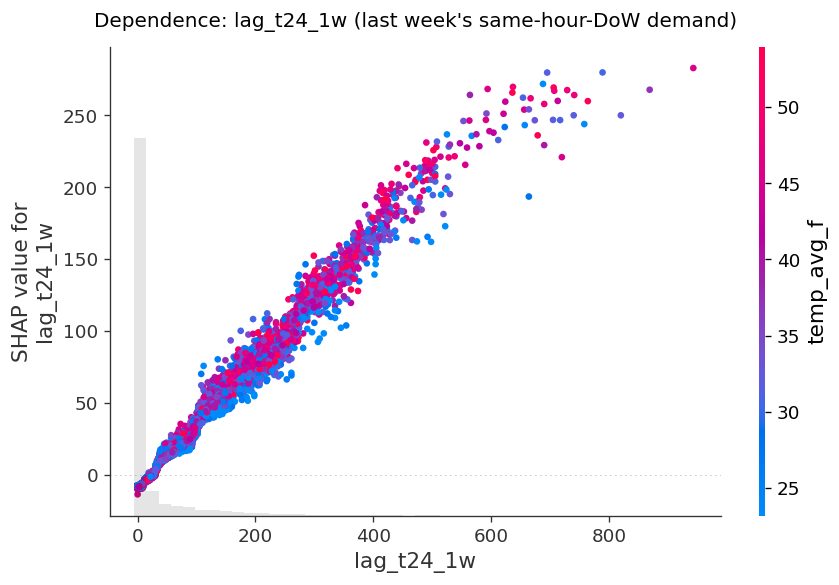

In [21]:
Image(str(config.PLOTS_DIR / 'shap_dependence_lag_t24_1w.png'))

## 8. Limitations and what's next

### What this model isn't

- **Not real-time.** The pipeline pulls from Snowflake batch. For live forecasting, you'd add a streaming inference layer.
- **Not an event-aware model.** Concerts, sports, parades, weather emergencies all spike demand. The model doesn't see them. A natural next step would be joining external event-calendar data and surfacing it as features.
- **Not multi-horizon.** A single model predicts t+24 only. Forecasting t+1 through t+24 would either need 24 models or a recursive inference loop where predicted values feed into subsequent lags.
- **Not multi-modal.** Pickup demand only — doesn't model dropoffs, fares, or driver supply. Pairing with a supply-side model would enable dispatch-aware predictions.

### Where the residual error lives

Manhattan's MAE of ~13 trips/hour at zone grain is the largest absolute error in the model. Two contributors:
1. **Volume.** Manhattan zones average dozens to hundreds of trips/hour — small percentage errors translate to big absolute ones.
2. **Variance.** High-volume zones also have higher hour-to-hour noise. Some of this is genuine demand volatility (events, weather extremes); some is upstream data noise.

### Fast wins for a follow-up phase

| Idea | Expected impact | Effort |
|---|---|---|
| Cross-zone features (borough-level rolling avg, citywide trend) | Could capture macro-level shocks (mass weather event, NYC marathon weekend) | Half-day |
| Hourly weather (currently daily, repeated 24×) | Should help on event-driven hours (afternoon thunderstorms, blizzards) | Day, requires NOAA hourly data ingest |
| Target encoding for high-cardinality `pickup_zone` | Replaces sparse one-hots with smoother per-zone signal | Half-day |
| Quantile regression (predict P10 / P50 / P90 instead of mean) | Useful if downstream cares about overflow risk, not point predictions | Day |
| LSTM / temporal CNN | Could capture longer-range dependencies the GBM misses | Multiple days, GPU helpful |

### What I'd say in an interview

*"The model beat a hard baseline by 6.4% on out-of-sample data. The interesting part wasn't the headline number — it was the diagnostic process. The first model barely cleared the baseline at 1.1%. SHAP analysis revealed why: I had a lag feature for 'one week before now' but the model was predicting 'one week before 24 hours from now' — a 24-hour offset between the feature and where the seasonal signal actually lived. Adding properly-aligned lags lifted us to 5.3%, and Optuna tuning brought us to 6.4%. The lesson is that careful diagnostic reading of a model's first underwhelming output is worth more than any amount of hyperparameter tuning."*